In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,Dropout,Input
from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings('ignore')

In [2]:
(x_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()

# 2. Slice exactly 60,000 rows
x_subset = x_train[:60000]
y_subset = y_train[:60000]

# 3. Flatten the 28x28 images into a 784-element 1D array
# Reshape from (60000, 28, 28) to (60000, 784)
x_flattened = x_subset.reshape(60000, 784)

# 4. Combine label and pixels into one matrix (60000, 785)
# We place the label as the first column
dataset_matrix = np.hstack((y_subset.reshape(-1, 1), x_flattened))

# 5. Create column headers: 'label', 'pixel0', 'pixel1', ..., 'pixel783'
columns = ["label"] + [f"pixel{i}" for i in range(784)]

# 6. Save to CSV
df = pd.DataFrame(dataset_matrix, columns=columns)
df.to_csv("mnist_6000_pixels.csv", index=False)

print(f"Dataset created with shape: {df.shape}")  # Outputs: (60000, 785)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset created with shape: (60000, 785)


In [3]:
df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(60000, 785)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel783
dtypes: uint8(785)
memory usage: 44.9 MB


In [6]:
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [7]:
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [ ]:
df=df.astype("float32")/255.0

In [8]:
X=df.drop('label',axis=1).values
y=df['label'].values

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [11]:
X_train_img= X_train.reshape(-1,28,28)
X_test_img= X_test.reshape(-1,28,28)

In [13]:
y_train_cat= to_categorical(y_train,10)
y_test_cat= to_categorical(y_test,10)

In [15]:
perceptron= Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')
])

In [16]:
perceptron.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

In [17]:
history_pred=perceptron.fit(X_train_img,y_train_cat,epochs=10,batch_size=32,validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8349 - loss: 332.2079 - val_accuracy: 0.3922 - val_loss: 3303.1858
Epoch 2/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8631 - loss: 266.2242 - val_accuracy: 0.8806 - val_loss: 223.8964
Epoch 3/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8698 - loss: 260.0400 - val_accuracy: 0.8504 - val_loss: 315.1459
Epoch 4/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8736 - loss: 248.2636 - val_accuracy: 0.8932 - val_loss: 212.4255
Epoch 5/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8754 - loss: 245.2290 - val_accuracy: 0.8850 - val_loss: 239.1424
Epoch 6/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8812 - loss: 230.8615 - val_accuracy: 0.8863 - val_loss: 238.2036
Epoch 7/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8773 - loss: 240.7955 - val_accuracy: 0.8136 - val_loss: 426.7542
Epoch 8/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accur

In [18]:
acc_percp= perceptron.evaluate(X_test_img,y_test_cat)[1]

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8108 - loss: 577.4471


In [20]:
#ANN
ann= Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [21]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [39]:
history_ann=ann.fit(X_train_img,y_train_cat,epochs=10,batch_size=32,validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9722 - loss: 0.1043 - val_accuracy: 0.9571 - val_loss: 0.1851
Epoch 2/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9747 - loss: 0.0887 - val_accuracy: 0.9609 - val_loss: 0.1733
Epoch 3/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9773 - loss: 0.0805 - val_accuracy: 0.9582 - val_loss: 0.1930
Epoch 4/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9782 - loss: 0.0815 - val_accuracy: 0.9648 - val_loss: 0.1738
Epoch 5/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9799 - loss: 0.0727 - val_accuracy: 0.9630 - val_loss: 0.1824
Epoch 6/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9784 - loss: 0.0770 - val_accuracy: 0.9646 - val_loss: 0.1846
Epoch 7/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9810 - loss: 0.0673 - val_accuracy: 0.9648 - val_loss: 0.1977
Epoch 8/10
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9827 - loss: 0.0629 

In [23]:
acc_ann= ann.evaluate(X_test_img,y_test_cat)[1]

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9577 - loss: 0.1736


In [31]:
X_train_cnn= X_train.reshape(-1,28,28,1)
X_test_cnn= X_test.reshape(-1,28,28,1)

In [40]:
#CNN
cnn= Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

In [41]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [42]:
history_cnn=cnn.fit(X_train_cnn,y_train_cat,epochs=5,batch_size=32,validation_data=(X_test_cnn,y_test_cat),verbose=1)

Epoch 1/5
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 48s 37ms/step - accuracy: 0.8677 - loss: 0.6365 - val_accuracy: 0.9595 - val_loss: 0.1299
Epoch 2/5
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.9533 - loss: 0.1645 - val_accuracy: 0.9776 - val_loss: 0.0765
Epoch 3/5
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.9659 - loss: 0.1211 - val_accuracy: 0.9807 - val_loss: 0.0685
Epoch 4/5
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 90s 40ms/step - accuracy: 0.9709 - loss: 0.0975 - val_accuracy: 0.9829 - val_loss: 0.0663
Epoch 5/5
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 53s 42ms/step - accuracy: 0.9731 - loss: 0.0911 - val_accuracy: 0.9830 - val_loss: 0.0635


In [43]:
acc_cnn= cnn.evaluate(X_test_cnn,y_test_cat)[1]

619/619 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9830 - loss: 0.0635


In [45]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

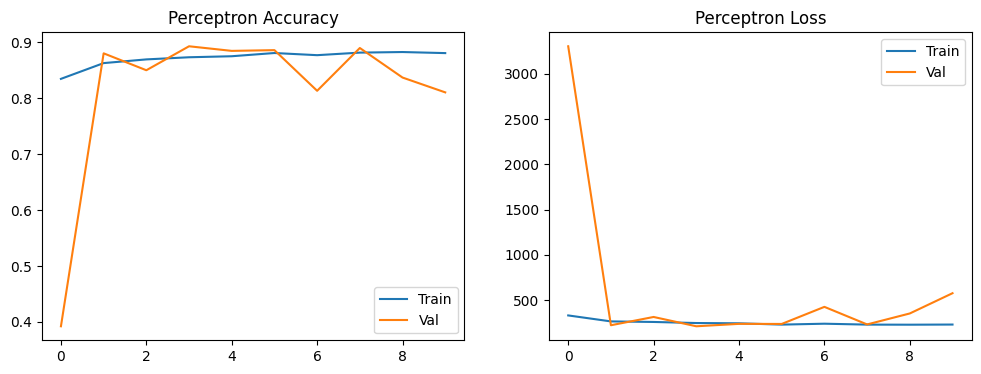

In [46]:
plot_training(history_pred, "Perceptron")

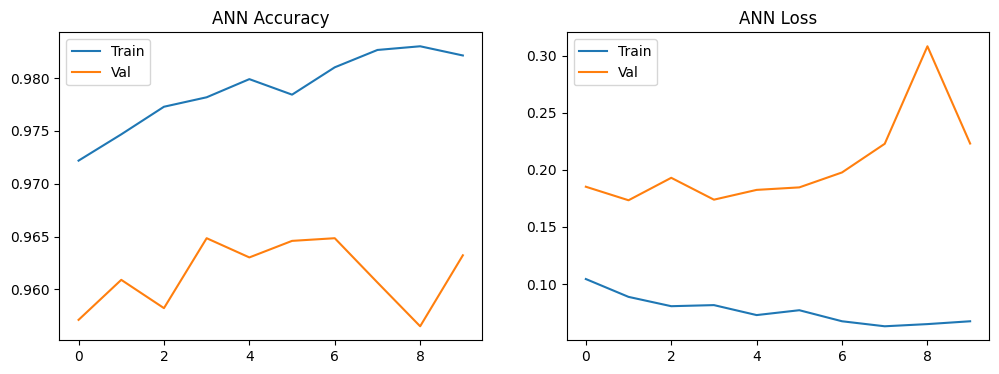

In [48]:
plot_training(history_ann, "ANN")

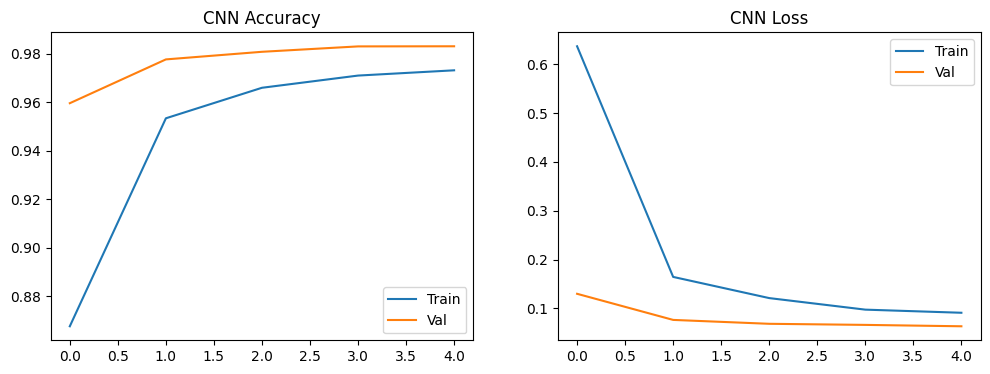

In [49]:
plot_training(history_cnn, "CNN")

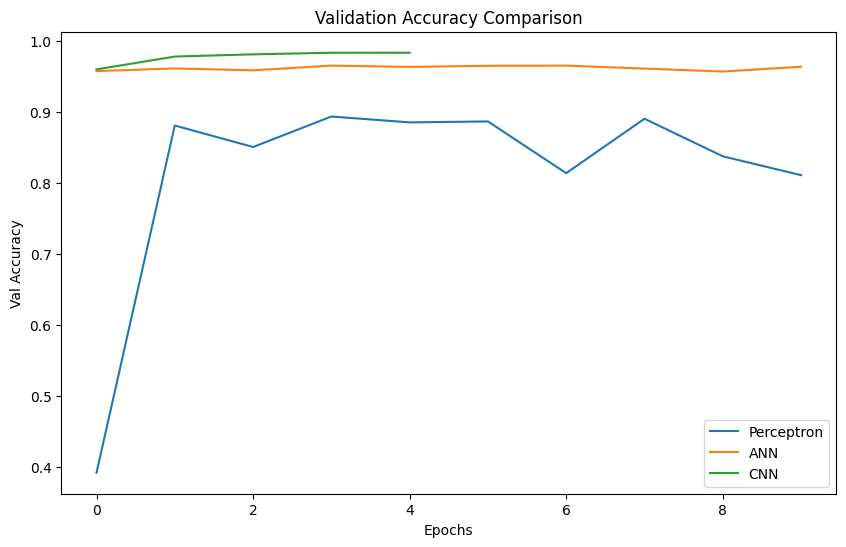

In [50]:
plt.figure(figsize=(10,6))
plt.plot(history_pred.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [54]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    # 1. Select the random indices upfront
    idxs = np.random.choice(len(X), n, replace=False)

    # 2. Slice the data batches for predictions to avoid looping over individual .predict()
    X_batch = X[idxs]          # Shape: (n, 28, 28) or (n, 784) depending on your data
    X_cnn_batch = X_cnn[idxs]  # Shape: (n, 28, 28, 1)

    # 3. Get ALL predictions at once
    all_preds = {}
    for model, name in zip(models, model_names):
        if name == "CNN":
            raw_preds = model.predict(X_cnn_batch, verbose=0) # verbose=0 silences the progress bar
        else:
            raw_preds = model.predict(X_batch, verbose=0)

        # Convert probabilities to class labels for the whole batch
        all_preds[name] = np.argmax(raw_preds, axis=1)

    # 4. Plotting
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        # Top Row: True Image
        plt.subplot(2, n, i + 1)
        # Ensure it's reshaped properly for display regardless of original flattening
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")

        # Bottom Row: Model Predictions text
        plt.subplot(2, n, n + i + 1)
        plt.axis("off")

        # Pull predictions from our pre-calculated dictionary using the loop index `i`
        pred_strings = [f"{name}: {all_preds[name][i]}" for name in model_names]
        plt.title("\n".join(pred_strings))

    plt.tight_layout()
    plt.show()

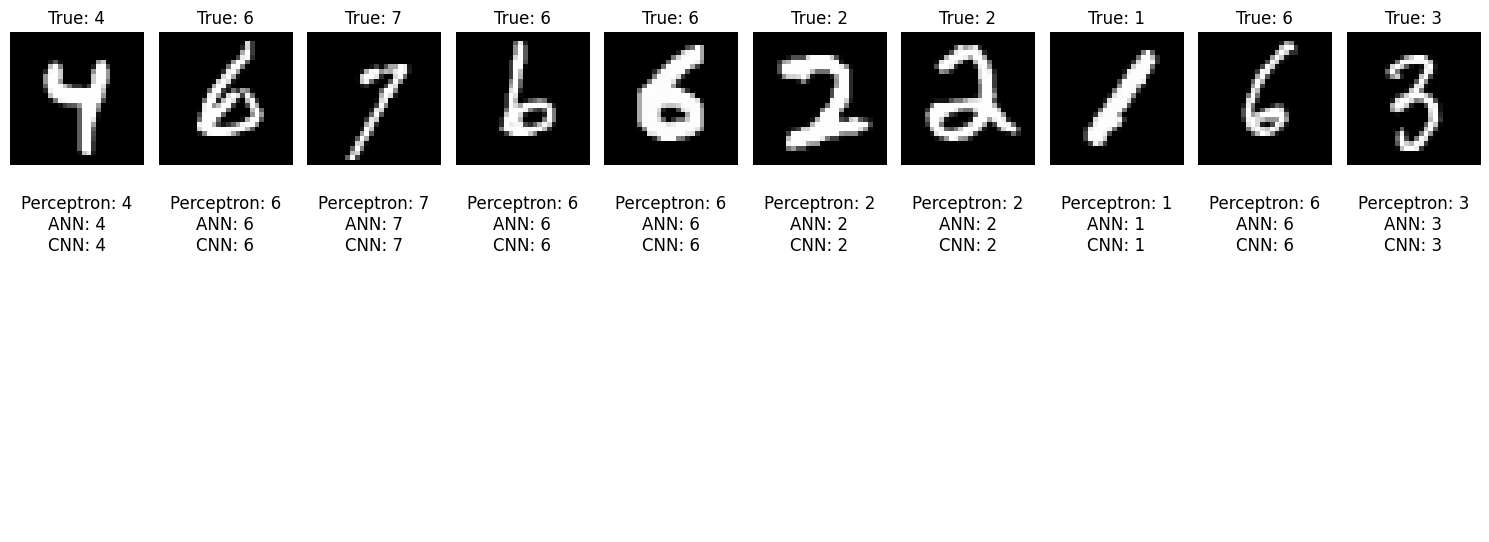

In [56]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test,10)

619/619 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step


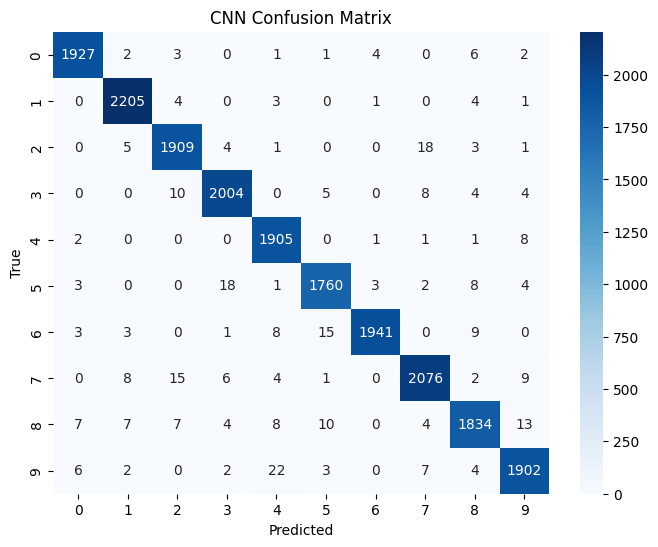

In [57]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

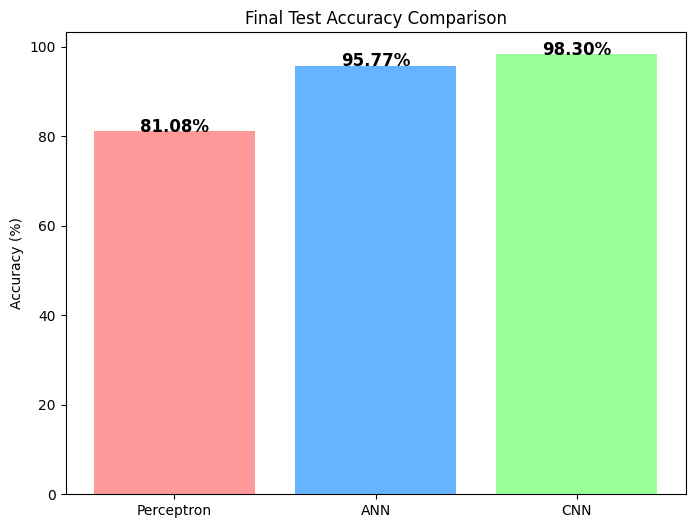

In [59]:
final_accs = [acc_percp*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
# plt.ylim(80, 100)
plt.show()